Data Collection

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 2.8 MB/s  0:00:03 eta 0:00:01


In [4]:
import plotly.express as px

In [5]:
import glob

In [7]:
len(glob.glob("/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/*csv"))

505

In [8]:
glob.glob("/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/*csv")

['/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/XRX_data.csv',
 '/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/GS_data.csv',
 '/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/SPGI_data.csv',
 '/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/MTB_data.csv',
 '/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/V_data.csv',
 '/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/CTAS_data.csv',
 '/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/ESRX_data.csv',
 '/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/APH_data.csv',
 '/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/BBT_data.csv',
 '/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individ

In [9]:
company_list = {
         '/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/AAPL_data.csv',
     '/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/AMZN_data.csv',
     '/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/GOOG_data.csv',
     '/Users/akash/Desktop/PROJECTS-Placements/Stock-Market-CaseStudy/individual_stocks_5yr/MSFT_data.csv',
     

}

In [10]:
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

In [14]:
all_data = pd.DataFrame()

for file in company_list:
    current_df = pd.read_csv(file)
    all_data = pd.concat([all_data,current_df],ignore_index=True)

In [15]:
all_data.shape

(4752, 7)

In [16]:
all_data.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


Data Cleaning and Preparation

In [17]:
all_data.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name'], dtype='str')

In [18]:
all_data.dtypes

date          str
open      float64
high      float64
low       float64
close     float64
volume      int64
Name          str
dtype: object

In [19]:
all_data['date'] = pd.to_datetime(all_data['date'])

In [20]:
all_data.dtypes

date      datetime64[us]
open             float64
high             float64
low              float64
close            float64
volume             int64
Name                 str
dtype: object

In [23]:
all_data.isnull().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

In [25]:
all_data['date']

0      2013-02-08
1      2013-02-11
2      2013-02-12
3      2013-02-13
4      2013-02-14
          ...    
4747   2018-02-01
4748   2018-02-02
4749   2018-02-05
4750   2018-02-06
4751   2018-02-07
Name: date, Length: 4752, dtype: datetime64[us]

In [26]:
all_data.duplicated().sum()

0

In [27]:
all_data[all_data['volume']<=0]

,date,open,high,low,close,volume,Name


In [28]:
all_data['Name'].unique()

<ArrowStringArray>
['AAPL', 'AMZN', 'MSFT', 'GOOG']
Length: 4, dtype: str

In [29]:
all_data.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


In [30]:
all_data = all_data.sort_values(['Name', 'date'])

In [31]:
all_data

,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL
...,...,...,...,...,...,...,...
3772,2018-02-01,94.7900,96.0700,93.5813,94.2600,47227882,MSFT
3773,2018-02-02,93.6400,93.9700,91.5000,91.7800,47867753,MSFT
3774,2018-02-05,90.5600,93.2400,88.0000,88.0000,51031465,MSFT
3775,2018-02-06,86.8900,91.4750,85.2500,91.3300,67998564,MSFT


Which is the Safest Stock to invest?
find the %change in closing prices

In [34]:
all_data['daily_return']=all_data.groupby('Name')['close'].pct_change()

In [36]:
risk = all_data.groupby('Name')['daily_return'].std()

In [37]:
risk

Name
AAPL    0.014593
AMZN    0.018235
GOOG    0.014069
MSFT    0.014210
Name: daily_return, dtype: float64

In [40]:
safest_stock = risk.idxmin()

In [41]:
safest_stock

'GOOG'

Which Stock has the Highest Money?

In [42]:
all_data.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name',
       'daily_return'],
      dtype='str')

In [43]:
all_data['daily_return']

0            NaN
1       0.010422
2      -0.025067
3      -0.001903
4      -0.000899
          ...   
3772   -0.007894
3773   -0.026310
3774   -0.041185
3775    0.037841
3776   -0.018833
Name: daily_return, Length: 4752, dtype: float64

In [44]:
all_data['cummulative_return'] = (1 + all_data['daily_return']).groupby(all_data['Name']).cumprod()

In [45]:
all_data['cummulative_return']

0            NaN
1       1.010422
2       0.985095
3       0.983220
4       0.982336
          ...   
3772    3.421416
3773    3.331397
3774    3.194192
3775    3.315064
3776    3.252632
Name: cummulative_return, Length: 4752, dtype: float64

In [46]:
all_data.groupby('Name')["cummulative_return"].last()

Name
AAPL    2.351218
AMZN    5.408589
GOOG    1.877628
MSFT    3.252632
Name: cummulative_return, dtype: float64

In [47]:
final_return = all_data.groupby('Name')["cummulative_return"].last()

In [48]:
final_return

Name
AAPL    2.351218
AMZN    5.408589
GOOG    1.877628
MSFT    3.252632
Name: cummulative_return, dtype: float64

In [50]:
best_stock = final_return.idxmax()

In [51]:
best_stock

'AMZN'

PLOT

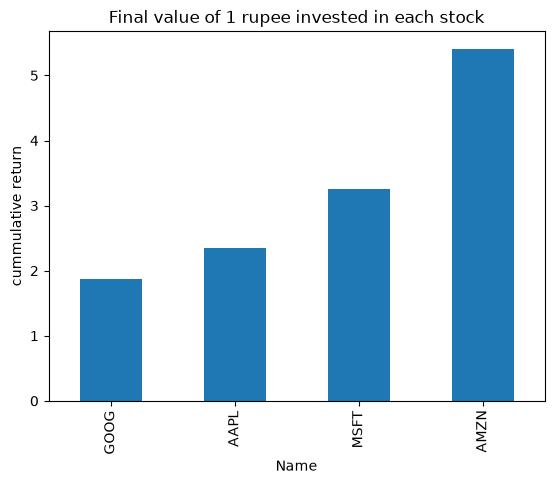

In [52]:
final_return.sort_values().plot(kind='bar')
plt.title("Final value of 1 rupee invested in each stock")
plt.ylabel("cummulative return")
plt.show()

Rs. 1 Lakh/Million Safe Investment simulation

In [53]:
investment = 100000

In [55]:
df_best = all_data[all_data['Name'] == best_stock]

In [57]:
df_best['investment_vale'] = df_best['cummulative_return'] * investment

In [58]:
df_best['investment_vale']

1259              NaN
1260     98190.494369
1261     98759.305211
1262    102870.776866
1263    102782.973850
            ...      
2513    530635.617484
2514    545886.619584
2515    530635.617484
2516    550807.405994
2517    540858.942546
Name: investment_vale, Length: 1259, dtype: float64

In [60]:
df_best['investment_vale'].tail(1).values[0]

540858.9425462884

Plot

In [61]:
df_best.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name',
       'daily_return', 'cummulative_return', 'investment_vale'],
      dtype='str')

In [62]:
px.line(df_best,
        x='date',
        y='investment_vale',
        title= f"1 Million Investement growth - {best_stock}",
        labels = {
            'investment value' : 'Portfolio Value'
        })

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'date=%{x}<br>investment_vale=%{y}<extra></extra>',
              'legendgroup': '',
              'line': {'color': '#636efa', 'dash': 'solid'},
              'marker': {'symbol': 'circle'},
              'mode': 'lines',
              'name': '',
              'showlegend': False,
              'type': 'scattergl',
              'x': array(['2013-02-08T00:00:00.000000', '2013-02-11T00:00:00.000000',
                          '2013-02-12T00:00:00.000000', ..., '2018-02-05T00:00:00.000000',
                          '2018-02-06T00:00:00.000000', '2018-02-07T00:00:00.000000'],
                         dtype='datetime64[us]'),
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAA+H9moe/o5/j3QPrXJOJ0HP' ... 'yXMSBBqmHezy7PIEFXbZXidYEgQQ=='),
                    'dtype': 'f8'},
              'yaxis': 'y'}],
    'layout': {'legend': {'tracegroupgap': 0},
               'template': '...',
               'title': {'text': '1 Million Investement growth - AMZN'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'date'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'investment_vale'}}}
})

Market Crash Days : Worst Losses Analysis

In [82]:
all_data[all_data["Name"]== 'AAPL'].nsmallest(5, 'daily_return')

,date,open,high,low,close,volume,Name,daily_return,cummulative_return
243,2014-01-28,72.6799,73.5714,71.7242,72.3571,266833581,AAPL,-0.079927,1.066361
746,2016-01-27,96.0400,96.6289,93.3400,93.4200,133369674,AAPL,-0.065707,1.376775
809,2016-04-27,96.0000,98.7100,95.6800,97.8200,114602142,AAPL,-0.062578,1.441620
638,2015-08-21,110.4300,111.9000,105.6450,105.7600,128275471,AAPL,-0.061163,1.558636
46,2013-04-17,60.0385,60.0857,56.8728,57.5428,236138966,AAPL,-0.054993,0.848036


In [83]:
worst_days = all_data.groupby('Name').apply(lambda x:x.nsmallest(5, "daily_return"))

In [86]:
worst_days = (
    all_data.groupby('Name')
    .apply(lambda x: x.nsmallest(5, 'daily_return'))
    .reset_index(level=0)
)

In [87]:
worst_days

,Name,date,open,high,low,close,volume,daily_return,cummulative_return
243,AAPL,2014-01-28,72.6799,73.5714,71.7242,72.3571,266833581,-0.079927,1.066361
746,AAPL,2016-01-27,96.0400,96.6289,93.3400,93.4200,133369674,-0.065707,1.376775
809,AAPL,2016-04-27,96.0000,98.7100,95.6800,97.8200,114602142,-0.062578,1.441620
638,AAPL,2015-08-21,110.4300,111.9000,105.6450,105.7600,128275471,-0.061163,1.558636
46,AAPL,2013-04-17,60.0385,60.0857,56.8728,57.5428,236138966,-0.054993,0.848036
1505,AMZN,2014-01-31,371.7600,375.4500,357.7600,358.6900,16181519,-0.109972,1.369307
1563,AMZN,2014-04-25,316.2500,316.4900,302.7100,303.8300,16186737,-0.098828,1.159878
1626,AMZN,2014-07-25,317.3000,324.8700,314.7600,324.0100,17855141,-0.096484,1.236915
1690,AMZN,2014-10-24,284.4000,293.8100,284.0000,287.0600,19805911,-0.083403,1.095858
2007,AMZN,2016-01-29,571.9800,593.0000,570.0000,587.0000,14677550,-0.076100,2.240886


In [88]:
worst_days.dtypes

Name                             str
date                  datetime64[us]
open                         float64
high                         float64
low                          float64
close                        float64
volume                         int64
daily_return                 float64
cummulative_return           float64
dtype: object

In [95]:
!pip install -U nbformat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [nbformat]


In [97]:
import nbformat
print(nbformat.__version__)


5.11.0


In [101]:
fig = px.bar(
    worst_days,
    x='date',
    y='daily_return',
    color="Name",
    title = "Worst market Crash days (Top Losses)"
)


In [102]:
pio.renderers.default = "browser"
fig.show()

In [103]:
worst_days["Crash_labels"]= worst_days['Name'] + " | " + worst_days["date"].dt.strftime("%Y-%m-%d")

In [104]:
worst_days

,Name,date,open,high,low,close,volume,daily_return,cummulative_return,Crash_labels
243,AAPL,2014-01-28,72.6799,73.5714,71.7242,72.3571,266833581,-0.079927,1.066361,AAPL | 2014-01-28
746,AAPL,2016-01-27,96.0400,96.6289,93.3400,93.4200,133369674,-0.065707,1.376775,AAPL | 2016-01-27
809,AAPL,2016-04-27,96.0000,98.7100,95.6800,97.8200,114602142,-0.062578,1.441620,AAPL | 2016-04-27
638,AAPL,2015-08-21,110.4300,111.9000,105.6450,105.7600,128275471,-0.061163,1.558636,AAPL | 2015-08-21
46,AAPL,2013-04-17,60.0385,60.0857,56.8728,57.5428,236138966,-0.054993,0.848036,AAPL | 2013-04-17
1505,AMZN,2014-01-31,371.7600,375.4500,357.7600,358.6900,16181519,-0.109972,1.369307,AMZN | 2014-01-31
1563,AMZN,2014-04-25,316.2500,316.4900,302.7100,303.8300,16186737,-0.098828,1.159878,AMZN | 2014-04-25
1626,AMZN,2014-07-25,317.3000,324.8700,314.7600,324.0100,17855141,-0.096484,1.236915,AMZN | 2014-07-25
1690,AMZN,2014-10-24,284.4000,293.8100,284.0000,287.0600,19805911,-0.083403,1.095858,AMZN | 2014-10-24
2007,AMZN,2016-01-29,571.9800,593.0000,570.0000,587.0000,14677550,-0.076100,2.240886,AMZN | 2016-01-29


In [105]:
fig = px.bar(
    worst_days,
    x='Crash_labels',
    y='daily_return',
    color="Name",
    title = "Worst market Crash days (Top Losses)"
)


In [108]:
pio.renderers.default = "browser"
fig.show()

Moving Average (Trend analysis)

In [109]:
all_data["MA20"] = all_data.groupby('Name')["close"].transform(lambda x:x.rolling(20).mean())

In [110]:
all_data["MA50"] = all_data.groupby('Name')["close"].transform(lambda x:x.rolling(50).mean())

In [112]:
all_data.head(25)

,date,open,high,low,close,volume,Name,daily_return,cummulative_return,MA20,MA50
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,NaN,NaN,NaN,NaN
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,0.010422,1.010422,NaN,NaN
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,-0.025067,0.985095,NaN,NaN
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,-0.001903,0.983220,NaN,NaN
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL,-0.000899,0.982336,NaN,NaN
5,2013-02-15,66.9785,67.1656,65.7028,65.7371,97924631,AAPL,-0.013780,0.968799,NaN,NaN
6,2013-02-19,65.8714,66.1042,64.8356,65.7128,108854046,AAPL,-0.000370,0.968441,NaN,NaN
7,2013-02-20,65.3842,65.3842,64.1142,64.1214,118891367,AAPL,-0.024218,0.944988,NaN,NaN
8,2013-02-21,63.7142,64.1671,63.2599,63.7228,111596821,AAPL,-0.006216,0.939114,NaN,NaN
9,2013-02-22,64.1785,64.5142,63.7999,64.4014,82583823,AAPL,0.010649,0.949114,NaN,NaN


In [113]:
df_stock = all_data[all_data["Name"] == "AAPL"]

In [114]:
df_stock.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name',
       'daily_return', 'cummulative_return', 'MA20', 'MA50'],
      dtype='str')

In [115]:
px.line(df_stock,
        x='date',
        y=['close','MA20','MA50'],
        title = "AAPL price with moving average")

Best Month to invest in each stock??  
which month historically gives you the highest average return for each stock

In [117]:
all_data["Month_name"]=all_data["date"].dt.month_name()

In [118]:
all_data.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'Name',
       'daily_return', 'cummulative_return', 'MA20', 'MA50', 'Month_name'],
      dtype='str')

In [121]:
monthly_returns = all_data.groupby(["Name", "Month_name"])['daily_return'].mean().reset_index()

In [122]:
monthly_returns.columns

Index(['Name', 'Month_name', 'daily_return'], dtype='str')

In [125]:
px.bar(
    monthly_returns,
    x= "Month_name",
    y= "daily_return",
    color = "Name",
    barmode = "group",
    title = "Average Monthly returns by stock"

)